In [1]:
import os; os.environ['WORKDIR'] = "/home/choij/workspace/ChargedHiggsAnalysis"
import sys; sys.path.insert(0, os.environ['WORKDIR'])

In [2]:
# load files and models
MASSPOINT = "MHc-100_MA-60"
BACKGROUND = "TTLL_powheg"
ERA = "2018"

from ROOT import TFile
from libPython.Preprocessor import rtfile_to_datalist
from libPython.Preprocessor import MyDataset
from sklearn.utils import shuffle
from torch_geometric.loader import DataLoader

f_sig = TFile.Open(f"{os.environ['WORKDIR']}/SelectorOutput/Selector_TTToHcToWAToMuMu_{MASSPOINT}.root")
f_bkg = TFile.Open(f"{os.environ['WORKDIR']}/SelectorOutput/Selector_{BACKGROUND}.root")

max_size = 100
sigDatalist = rtfile_to_datalist(f_sig, channel="3Mu", is_signal=True, is_prompt=True, max_size=max_size)
bkgDatalist = rtfile_to_datalist(f_bkg, channel="3Mu", is_signal=False, is_prompt=False, max_size=max_size)
f_sig.Close()
f_bkg.Close()

sigDatalist = shuffle(sigDatalist, random_state=42)[:max_size]
bkgDatalist = shuffle(bkgDatalist, random_state=42)[:max_size]
datalist = shuffle(sigDatalist+bkgDatalist, random_state=42)

trainDataset = MyDataset(datalist[:int(max_size*2*0.4)])
validDataset = MyDataset(datalist[int(max_size*2*0.4):int(max_size*2*0.5)])
testDataset = MyDataset(datalist[int(max_size*2*0.5):])

trainLoader = DataLoader(trainDataset, batch_size=1024, shuffle=True, pin_memory=True)
validLoader = DataLoader(validDataset, batch_size=1024, shuffle=False, pin_memory=True)
testLoader = DataLoader(testDataset, batch_size=1024, shuffle=False, pin_memory=True)

Welcome to JupyROOT 6.26/06


In [3]:
# load model
import torch
from libPython.MLTools import ParticleNet
OPTIM = "AdamW"
InitLR = 0.02
SCHEDULER = "StepLR"
model_path = f"{os.environ['WORKDIR']}/models/pilot/{MASSPOINT}_vs_{BACKGROUND}/ParticleNet_{OPTIM}_initLR-{str(InitLR).replace('.', 'p')}_{SCHEDULER}.pt"
model = ParticleNet(num_features=9, num_classes=2, hidden_channels=128)
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))

<All keys matched successfully>

In [4]:
from libPython.DataFormat import get_muons, get_electrons, get_jets
from libPython.Selection import pass_baseline
from libPython.Preprocessor import get_edge_indices
from torch_geometric.data import Data
from ROOT import TH1D

model.eval()
#f = TFile.Open(f"{os.environ['WORKDIR']}/SelectorOutput/2017/Skim3Mu__/Split/Selector_TTToHcToWAToMuMu_{MASSPOINT}_0.root")
f = TFile.Open(f"{os.environ['WORKDIR']}/SelectorOutput/2017/Skim3Mu__/Split/Selector_TTLL_powheg_0.root")
data_list = []
h_nobatch = TH1D("h_nobatch", "", 100, 0., 1.)
h_nobatch.SetDirectory(0)
for evt in f.Events:
    muons = get_muons(evt)
    electrons = get_electrons(evt)
    jets, bjets = get_jets(evt)
    
    if not pass_baseline("3Mu", evt, muons, electrons, jets, bjets, "loose"):
        continue
    
    node_list = []
    for particle in muons+electrons+jets:
        node_list.append([particle.Pt(),
                            particle.Eta(),
                            particle.Phi(),
                            particle.M(),
                            particle.Charge(),
                            particle.IsMuon(),
                            particle.IsElectron(),
                            particle.IsJet(),
                            particle.BtagScore()]
                        )
    x = torch.tensor(node_list, dtype=torch.float)
    edge_index, edge_attribute = get_edge_indices(node_list, k=4)
    data = Data(x=x,
                y=int(False),
                edge_index=edge_index.t().contiguous(),
                edge_attribute=edge_attribute)
    with torch.no_grad():
        out = model(data.x, data.edge_index, batch=None)
        print(out)
        h_nobatch.Fill(out[0][1].numpy())
    data_list.append(data)
f.Close()

tensor([[0.6995, 0.3005]])
tensor([[8.8734e-08, 1.0000e+00]])
tensor([[0.7250, 0.2750]])
tensor([[0.6301, 0.3699]])
tensor([[0.7320, 0.2680]])
tensor([[0.5244, 0.4756]])
tensor([[0.6914, 0.3086]])
tensor([[1.0000e+00, 3.0001e-11]])
tensor([[0.3519, 0.6481]])
tensor([[0.1787, 0.8213]])
tensor([[0.4257, 0.5743]])
tensor([[0.5613, 0.4387]])
tensor([[0.1707, 0.8293]])
tensor([[0.5141, 0.4859]])
tensor([[6.0816e-04, 9.9939e-01]])
tensor([[0.3001, 0.6999]])
tensor([[0.0728, 0.9272]])
tensor([[0.4647, 0.5353]])
tensor([[0.6025, 0.3975]])
tensor([[0.5906, 0.4094]])
tensor([[0.6563, 0.3437]])
tensor([[0.3398, 0.6602]])
tensor([[0.8878, 0.1122]])
tensor([[0.0031, 0.9969]])
tensor([[0.0266, 0.9734]])
tensor([[0.3004, 0.6996]])
tensor([[0.2378, 0.7622]])
tensor([[1.0000e+00, 5.3027e-08]])
tensor([[0.3264, 0.6736]])
tensor([[1.0200e-09, 1.0000e+00]])
tensor([[0.4130, 0.5870]])
tensor([[0.0386, 0.9614]])
tensor([[0.0141, 0.9859]])
tensor([[0.6900, 0.3100]])
tensor([[0.0090, 0.9910]])
tensor([[0.4193

In [5]:
dataset = MyDataset(data_list)
loader = DataLoader(dataset, batch_size=1024, shuffle=False, pin_memory=True)

In [6]:
from ROOT import TCanvas
h = TH1D("h", "", 100, 0., 1)
model.eval()

for data in loader:
    with torch.no_grad():
        out = model(data.x, data.edge_index, data.batch)
    for p in out:
        h.Fill(p[1].numpy())

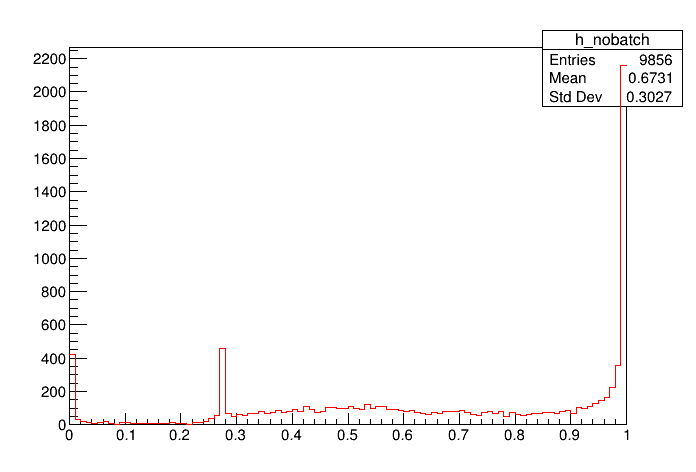

In [7]:
h_nobatch.SetLineColor(1)
h.SetLineColor(2)

c = TCanvas()
c.cd()
h_nobatch.Draw()
h.Draw("same")
c.Draw()

In [8]:
from libPython.MLTools import predict
from sklearn import metrics

answers, predictions = predict(model, trainLoader)
fpr, tpr, _ = metrics.roc_curve(answers, predictions, pos_label=1)
auc = metrics.auc(fpr, tpr)

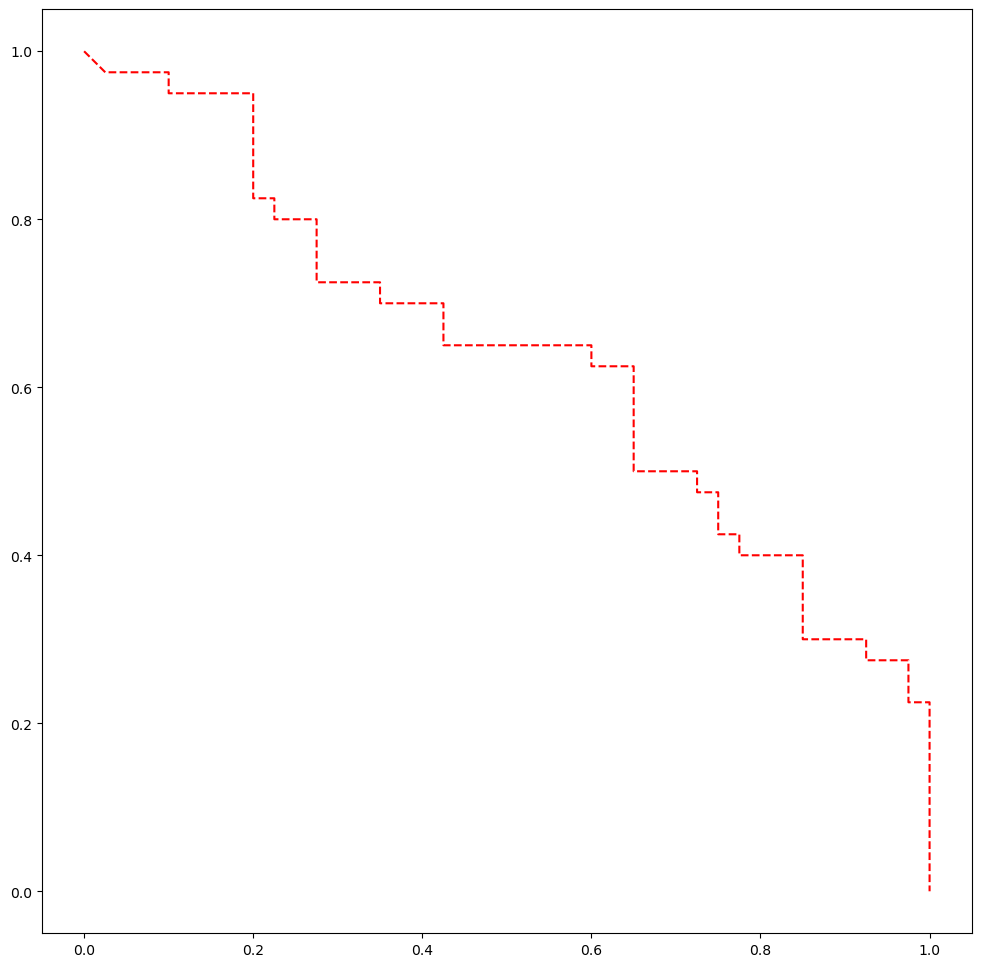

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 12))
plt.plot(tpr, 1-fpr, "r--")
plt.show()

In [30]:
from torch.nn import Sequential, Linear, ReLU
from torch.nn import Dropout
import torch.nn.functional as F
from torch_geometric.nn import GraphNorm
from torch_geometric.nn import MessagePassing
from torch_geometric.nn import knn_graph, global_mean_pool

class EdgeConv(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='mean')
        self.mlp = Sequential(Linear(2 * in_channels, out_channels), ReLU(),
                              Linear(out_channels, out_channels), ReLU(),
                              Linear(out_channels, out_channels))

    def forward(self, x, edge_index, batch):
        return self.propagate(edge_index, x=x, batch=batch)

    def message(self, x_i, x_j):
        tmp = torch.cat([x_i, x_j - x_i], dim=1)
        return self.mlp(tmp)

class DynamicEdgeConv(EdgeConv):
    def __init__(self, in_channels, out_channels, k=4):
        super().__init__(in_channels, out_channels)
        self.k = k

    def forward(self, x, edge_index=None, batch=None):
        if edge_index is None:
            edge_index = knn_graph(
                x, self.k, batch, loop=False, flow=self.flow)
        return super().forward(x, edge_index, batch=batch)

class ParticleNet(torch.nn.Module):
    def __init__(self, num_features, num_classes, hidden_channels, dynamic=True):
        super(ParticleNet, self).__init__()
        self.dynamic = dynamic
        self.gn0 = GraphNorm(num_features)
        self.conv1 = DynamicEdgeConv(num_features, hidden_channels)
        self.gn1 = GraphNorm(hidden_channels)
        self.conv2 = DynamicEdgeConv(hidden_channels, hidden_channels)
        self.gn2 = GraphNorm(hidden_channels)
        self.conv3 = DynamicEdgeConv(hidden_channels, hidden_channels)
        self.dropout = Dropout(p=0.5)
        self.dense = Linear(hidden_channels, hidden_channels)
        self.output = Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch=None):
        # Convolution layers
        x = self.gn0(x, batch=batch)
        x = self.conv1(x, edge_index, batch=batch)
        x = self.gn1(x, batch=batch)
        x = self.conv2(x, batch=batch) if self.dynamic else self.conv2(x, edge_index, batch=batch)
        x = self.gn2(x, batch=batch)
        x = self.conv3(x, batch=batch) if self.dynamic else self.conv3(x, edge_index, batch=batch)
        
        # readout layers
        x = global_mean_pool(x, batch=batch)

        # dense layers
        print(self.training)
        x = F.dropout(x, p=0.5, training=self.training)
        if batch is None:
            print(x)
        else:
            print(x[0])
        x = F.relu(self.dense(x))
        x = self.output(x)
            
        return F.softmax(x, dim=1)

In [32]:
net = ParticleNet(num_features=9, num_classes=2, hidden_channels=128)
net.eval()
for data_batch in testLoader:
    data = data_batch[0]
    out = net(data.x, data.edge_index)
    out_batch = net(data.x, data.edge_index, data.batch)
    break

False
False
tensor([[-0.0633, -0.1346,  0.0136, -0.0652, -0.1611,  0.1393,  0.0297,  0.0550,
          0.0031, -0.0765,  0.0822,  0.0213,  0.1174,  0.0180, -0.1071, -0.1222,
          0.0003,  0.0131,  0.0030,  0.1670,  0.0694,  0.0522,  0.1626, -0.0229,
          0.0558, -0.0855,  0.2151,  0.1947,  0.0117, -0.0071, -0.0118,  0.0316,
          0.1750, -0.0005,  0.0476,  0.0217, -0.1082, -0.0210,  0.0482, -0.1720,
         -0.0875,  0.0774,  0.1120,  0.1337, -0.0287,  0.1976, -0.0115, -0.1367,
         -0.0031, -0.1341,  0.0385,  0.0219, -0.0007, -0.0244, -0.0690,  0.0121,
         -0.0104,  0.0610, -0.0806, -0.0936,  0.2232, -0.0024, -0.0749, -0.0583,
          0.0555,  0.0282,  0.0861,  0.0839, -0.1164,  0.0336,  0.0359, -0.0718,
         -0.0628,  0.0211,  0.0631,  0.1166,  0.1370,  0.0566,  0.0844, -0.0470,
          0.0355,  0.0564,  0.0513, -0.0101, -0.1078,  0.0458, -0.1190, -0.0218,
         -0.0229, -0.0478, -0.1875, -0.2200,  0.0186, -0.0487, -0.1113, -0.1568,
         -0.1314